In [ ]:
!pip install -q transformers datasets evaluate accelerate
!pip install -q scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/BTech_Project'
RESULTS_PATH = os.path.join(PROJECT_PATH, 'comparison_results')
os.makedirs(RESULTS_PATH, exist_ok=True)
print(f"✅ Drive mounted. Results will be saved to: {RESULTS_PATH}")
!nvidia-smi


Mounted at /content/drive
✅ Drive mounted. Results will be saved to: /content/drive/MyDrive/BTech_Project/comparison_results
Wed Apr  8 12:50:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|              

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

print("✅ All imports successful")

✅ All imports successful


In [ ]:
CSV_FILE     = os.path.join(PROJECT_PATH, 'political_tweets_labeled.csv')
TEXT_COLUMN  = 'text'
LABEL_COLUMN = 'label'

LABEL_MAP   = {-1: 0, 0: 1, 1: 2}
ID2LABEL    = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
CLASS_NAMES = ['Negative', 'Neutral', 'Positive']

TEST_SIZE    = 0.2
RANDOM_STATE = 42
MAX_LEN      = 128
BATCH_SIZE   = 16
EPOCHS       = 5

all_results = {}
print("✅ Configuration set")

✅ Configuration set


In [ ]:
# ============================================================
# CELL 5 — LOAD DATA WITH DUPLICATE & NULL REMOVAL
# ============================================================

df = pd.read_csv(CSV_FILE)

print(f"Raw dataset size        : {len(df)}")
print(f"Null values:\n{df[[TEXT_COLUMN, LABEL_COLUMN]].isnull().sum()}")

# ── Step 1: Remove nulls ──
df = df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN])
print(f"\nAfter null removal      : {len(df)}")

# ── Step 2: Remove empty strings ──
df = df[df[TEXT_COLUMN].str.strip() != '']
print(f"After empty str removal : {len(df)}")

# ── Step 3: Remove duplicate tweets ──
before_dedup = len(df)
df = df.drop_duplicates(subset=[TEXT_COLUMN])
after_dedup  = len(df)
print(f"Duplicates removed      : {before_dedup - after_dedup}")
print(f"After dedup             : {after_dedup}")

# ── Step 4: Keep only relevant columns ──
df = df[[TEXT_COLUMN, LABEL_COLUMN]]

# ── Step 5: Map labels ──
df['label'] = df[LABEL_COLUMN].map(LABEL_MAP)

# ── Step 6: Remove any rows where label mapping failed ──
before_label = len(df)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)
print(f"Invalid labels removed  : {before_label - len(df)}")

# ── Final stats ──
print(f"\n{'='*40}")
print(f"Final dataset size      : {len(df)}")
print(f"Class balance:")
print(df['label'].value_counts()
      .rename(index=ID2LABEL)
      .to_string())
print(f"{'='*40}")

X = df[TEXT_COLUMN].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nTrain : {len(X_train)}  |  Test : {len(X_test)}")
print(f"✅ Data ready for training")

Raw dataset size        : 165637
Null values:
text     4
label    0
dtype: int64

After null removal      : 165633
After empty str removal : 165632
Duplicates removed      : 1
After dedup             : 165631
Invalid labels removed  : 0

Final dataset size      : 165631
Class balance:
label
Positive    56233
Neutral     55209
Negative    54189

Train : 132504  |  Test : 33127
✅ Data ready for training


In [ ]:
def save_confusion_matrix(cm, model_name):
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}',
                 fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    path = os.path.join(RESULTS_PATH, f'cm_{model_name.replace(" ","_")}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Confusion matrix saved → {path}")


def save_training_history(history, model_name):
    n_plots = 2 if 'train_loss' in history else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(14, 5))
    if n_plots == 1:
        axes = [axes]

    epochs_range = range(1, len(history['val_acc']) + 1)

    # Accuracy
    axes[0].plot(epochs_range, [v*100 for v in history['train_acc']],
                 'b-o', linewidth=2, markersize=6, label='Train Accuracy')
    axes[0].plot(epochs_range, [v*100 for v in history['val_acc']],
                 'r-o', linewidth=2, markersize=6, label='Val Accuracy')
    axes[0].set_title(f'{model_name} — Accuracy per Epoch',
                      fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Loss
    if 'train_loss' in history:
        axes[1].plot(epochs_range, history['train_loss'],
                     'b-o', linewidth=2, markersize=6, label='Train Loss')
        axes[1].plot(epochs_range, history['val_loss'],
                     'r-o', linewidth=2, markersize=6, label='Val Loss')
        axes[1].set_title(f'{model_name} — Loss per Epoch',
                          fontweight='bold', fontsize=13)
        axes[1].set_xlabel('Epoch', fontsize=12)
        axes[1].set_ylabel('Loss', fontsize=12)
        axes[1].legend(fontsize=11)
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    path = os.path.join(RESULTS_PATH,
                        f'history_{model_name.replace(" ","_")}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Training history saved → {path}")


def print_and_store(model_name, y_true, y_pred, history=None):
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )
    cm  = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{'='*60}")
    print(f"  {model_name}  —  Test Accuracy: {acc*100:.2f}%")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    all_results[model_name] = {
        'report'  : report,
        'cm'      : cm,
        'accuracy': acc,
        'history' : history
    }

    save_confusion_matrix(cm, model_name)
    if history:
        save_training_history(history, model_name)

print("✅ Helper functions defined")

✅ Helper functions defined



  MODEL 1 — SVM + TF-IDF
Training SVM...

  SVM  —  Test Accuracy: 94.35%
              precision    recall  f1-score   support

    Negative       0.94      0.92      0.93     10838
     Neutral       0.95      0.97      0.96     11042
    Positive       0.94      0.93      0.94     11247

    accuracy                           0.94     33127
   macro avg       0.94      0.94      0.94     33127
weighted avg       0.94      0.94      0.94     33127



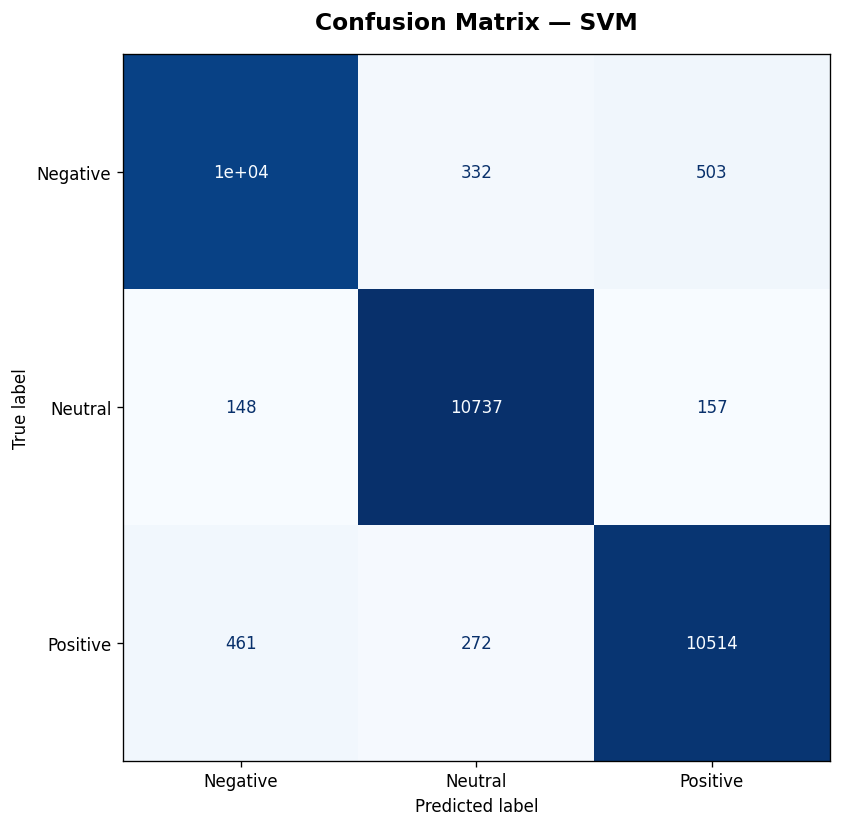

  ✅ Confusion matrix saved → /content/drive/MyDrive/BTech_Project/comparison_results/cm_SVM.png


In [ ]:
print("\n" + "="*60)
print("  MODEL 1 — SVM + TF-IDF")
print("="*60)

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True
    )),
    ('clf', CalibratedClassifierCV(LinearSVC(max_iter=2000)))
])

print("Training SVM...")
svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)
print_and_store('SVM', y_test, y_pred_svm)

✅ Using float32 precision
X_train_seq shape : (132504, 64)
Max token index   : 19999
Embedding size    : 20001
✅ Safe?          : True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training BiLSTM...
Epoch 1/5
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.8809 - loss: 0.3228 - val_accuracy: 0.9572 - val_loss: 0.1415
Epoch 2/5
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.9653 - loss: 0.1217 - val_accuracy: 0.9665 - val_loss: 0.1167
Epoch 3/5
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - accuracy: 0.9748 - loss: 0.0893 - val_accuracy: 0.9672 - val_loss: 0.1168
Epoch 4/5
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.9792 - loss: 0.0733 - val_accuracy: 0.9712 - val_loss: 0.1140
Epoch 5/5
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.9823 - loss: 0.0603 - val_accuracy: 0.9703 - val_loss: 0.1203
Restoring model weights from the end of the best epoch: 4.
518/518 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

  Bi-LSTM  —  Test Accuracy: 97.12%
              precision    recall  f1-score   support

    Negative       0.96      0.97      0.97     10838
     Neutral       0.99      0.97      0.98     11042
    Positive       0.97  

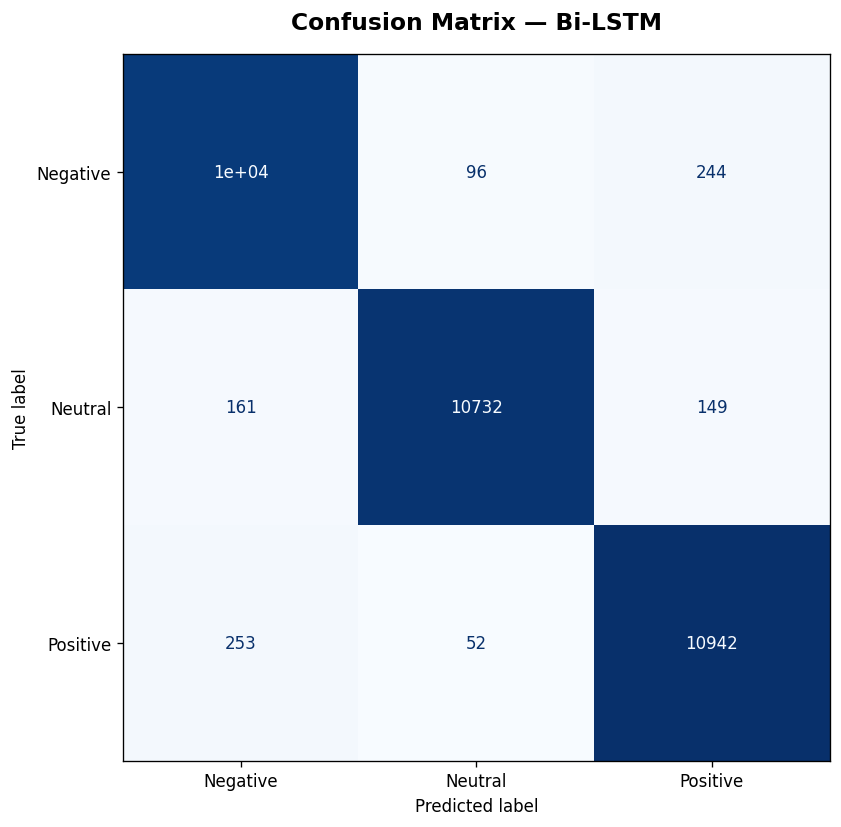

  ✅ Confusion matrix saved → /content/drive/MyDrive/BTech_Project/comparison_results/cm_Bi-LSTM.png


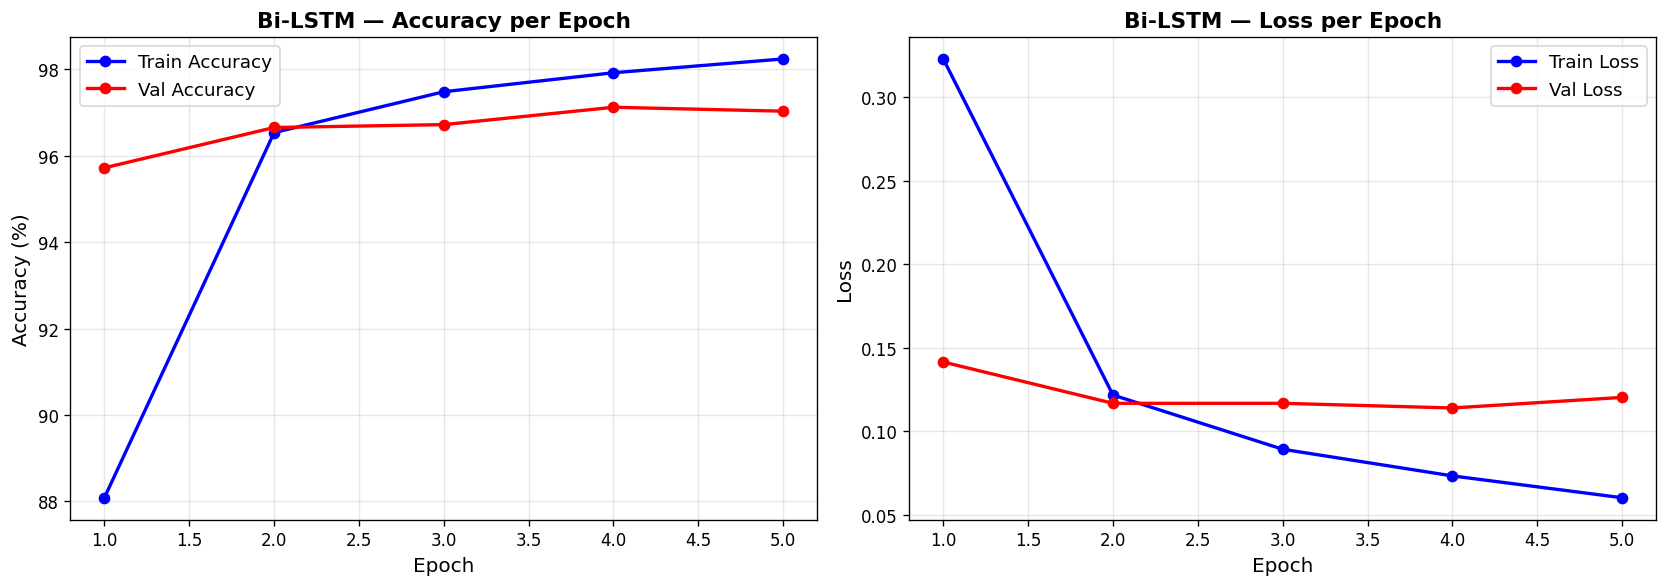

  ✅ Training history saved → /content/drive/MyDrive/BTech_Project/comparison_results/history_Bi-LSTM.png


In [ ]:
# ============================================================
# MODEL 2: BiLSTM — FIXED + OPTIMIZED FOR T4 GPU
# ============================================================

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout,
    Bidirectional, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping

# ── Disable mixed precision — it caused the InvalidArgumentError ──
tf.keras.mixed_precision.set_global_policy('float32')
print("✅ Using float32 precision")

# ── Settings ──
VOCAB_SIZE  = 20000
EMBED_DIM   = 64
LSTM_UNITS  = 64
MAX_LEN     = 64
BATCH_SIZE  = 64
EPOCHS      = 5

# ── KEY FIX: Add +1 to VOCAB_SIZE to account for OOV token index ──
# The OOV token gets index = VOCAB_SIZE which is OUT OF BOUNDS
# Adding +1 makes the embedding table large enough to include it
VOCAB_SIZE_WITH_OOV = VOCAB_SIZE + 1

# ── Tokenize ──
keras_tok = KerasTokenizer(
    num_words=VOCAB_SIZE,
    oov_token='<OOV>'
)
keras_tok.fit_on_texts(X_train)

X_train_seq = pad_sequences(
    keras_tok.texts_to_sequences(X_train),
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)
X_test_seq = pad_sequences(
    keras_tok.texts_to_sequences(X_test),
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

y_train_cat = tf.keras.utils.to_categorical(y_train, 3)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  3)

print(f"X_train_seq shape : {X_train_seq.shape}")
print(f"Max token index   : {X_train_seq.max()}")
print(f"Embedding size    : {VOCAB_SIZE_WITH_OOV}")
# Max token index must be < Embedding size — verify this prints True
print(f"✅ Safe?          : {X_train_seq.max() < VOCAB_SIZE_WITH_OOV}")

# ── tf.data pipeline for GPU speed ──
AUTOTUNE = tf.data.AUTOTUNE

train_dataset_tf = tf.data.Dataset.from_tensor_slices(
    (X_train_seq, y_train_cat)
).shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_dataset_tf = tf.data.Dataset.from_tensor_slices(
    (X_test_seq, y_test_cat)
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# ── Model — use VOCAB_SIZE_WITH_OOV in Embedding ──
lstm_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE_WITH_OOV,   # ← FIXED: was VOCAB_SIZE
        output_dim=EMBED_DIM,
        input_length=MAX_LEN
    ),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(
        LSTM_UNITS,
        dropout=0.2,
        recurrent_dropout=0.0            # ← keep 0.0 for GPU cuDNN kernel
    )),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

# ── Callbacks ──
es = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# ── Train ──
print("\nTraining BiLSTM...")
lstm_hist = lstm_model.fit(
    train_dataset_tf,
    validation_data=test_dataset_tf,
    epochs=EPOCHS,
    callbacks=[es],
    verbose=1
)

# ── Predict ──
y_pred_lstm = lstm_model.predict(
    test_dataset_tf, verbose=1
).argmax(axis=-1)

lstm_history = {
    'train_acc' : lstm_hist.history['accuracy'],
    'val_acc'   : lstm_hist.history['val_accuracy'],
    'train_loss': lstm_hist.history['loss'],
    'val_loss'  : lstm_hist.history['val_loss'],
}

print_and_store('Bi-LSTM', y_test, y_pred_lstm, history=lstm_history)


In [ ]:
# ============================================================
# SAVE BiLSTM
# ============================================================
bilstm_save_path = os.path.join(PROJECT_PATH, 'bilstm_model.keras')
lstm_model.save(bilstm_save_path)
print(f"✅ BiLSTM saved → {bilstm_save_path}")

# Save the keras tokenizer too (needed for ensemble)
import pickle
tok_save_path = os.path.join(PROJECT_PATH, 'keras_tokenizer.pkl')
with open(tok_save_path, 'wb') as f:
    pickle.dump(keras_tok, f)
print(f"✅ Keras tokenizer saved → {tok_save_path}")

✅ BiLSTM saved → /content/drive/MyDrive/BTech_Project/bilstm_model.keras
✅ Keras tokenizer saved → /content/drive/MyDrive/BTech_Project/keras_tokenizer.pkl


In [ ]:
# ============================================================
# CELL 9 — FIXED IMPORTS + YOUR SETTINGS
# ============================================================

import torch
from torch.utils.data import Dataset as TorchDataset, DataLoader
from torch.optim import AdamW                          # ✅ fixed
from torch.cuda.amp import autocast, GradScaler

from transformers import (
    AutoTokenizer as HF_Tokenizer,
    AutoModelForSequenceClassification as HF_Model,
    get_linear_schedule_with_warmup
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {DEVICE}")

# ── SPEED OPTIMIZATIONS ──
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

# ── YOUR SETTINGS ──
MAX_LEN    = 64   # ✅ as requested
BATCH_SIZE = 32
EPOCHS     = 5     # ✅ as requested

print(f"✅ MAX_LEN : {MAX_LEN}")
print(f"✅ EPOCHS  : {EPOCHS}")
print(f"✅ BATCH   : {BATCH_SIZE}")


# ============================================================
# TWEET DATASET — PRE-TOKENIZED
# ============================================================
class TweetDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.labels = labels
        print(f"  Pre-tokenizing {len(texts)} samples...")
        self.encodings = tokenizer(
            list(texts),
            padding='max_length',
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        )
        print(f"  ✅ Pre-tokenization complete")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'     : self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels'        : torch.tensor(
                                  self.labels[idx], dtype=torch.long)
        }


# ============================================================
# TRAINING LOOP
# ============================================================
def train_transformer(model_name_hf, run_name,
                      X_tr, y_tr, X_te, y_te,
                      epochs=EPOCHS,
                      batch_size=BATCH_SIZE,
                      lr=2e-5):

    print(f"\n{'='*55}")
    print(f"  Training : {run_name}")
    print(f"  Model    : {model_name_hf}")
    print(f"  Epochs   : {epochs}  |  Batch : {batch_size}  |  MaxLen : {MAX_LEN}")
    print(f"{'='*55}")

    # ── Tokenizer ──
    tok = HF_Tokenizer.from_pretrained(model_name_hf)

    # ── Datasets ──
    print("\nPreparing train dataset...")
    train_ds = TweetDataset(X_tr, y_tr, tok, MAX_LEN)
    print("Preparing test dataset...")
    val_ds   = TweetDataset(X_te, y_te, tok, MAX_LEN)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size * 2,   # larger batch for eval
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )

    # ── Model ──
    print(f"\nLoading model weights...")
    model = HF_Model.from_pretrained(
        model_name_hf,
        num_labels=3,
        id2label=ID2LABEL,
        label2id={v: k for k, v in ID2LABEL.items()},
        ignore_mismatched_sizes=True
    ).to(DEVICE)

    # ── Optimizer & Scheduler ──
    optimizer   = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )
    scaler = GradScaler()

    history = {
        'train_acc' : [], 'val_acc'   : [],
        'train_loss': [], 'val_loss'  : []
    }
    all_preds_final  = []
    all_labels_final = []

    for epoch in range(1, epochs + 1):
        import time
        epoch_start = time.time()

        # ── TRAIN ──────────────────────────────────
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for step, batch in enumerate(train_loader):
            ids    = batch['input_ids'].to(DEVICE, non_blocking=True)
            mask   = batch['attention_mask'].to(DEVICE, non_blocking=True)
            labels = batch['labels'].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast():
                out  = model(input_ids=ids,
                             attention_mask=mask,
                             labels=labels)
                loss = out.loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            total_loss += loss.item()
            preds       = out.logits.argmax(dim=-1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            # Progress every 50 steps
            if (step + 1) % 50 == 0:
                elapsed = time.time() - epoch_start
                print(f"    Step {step+1}/{len(train_loader)} "
                      f"| loss={total_loss/(step+1):.4f} "
                      f"| acc={correct/total*100:.1f}% "
                      f"| elapsed={elapsed:.0f}s")

        train_acc  = correct / total
        train_loss = total_loss / len(train_loader)

        # ── EVAL ───────────────────────────────────
        model.eval()
        val_loss_sum = 0.0
        val_correct  = 0
        val_total    = 0
        ep_preds     = []
        ep_labels    = []

        with torch.no_grad():
            for batch in val_loader:
                ids    = batch['input_ids'].to(DEVICE, non_blocking=True)
                mask   = batch['attention_mask'].to(DEVICE, non_blocking=True)
                labels = batch['labels'].to(DEVICE, non_blocking=True)

                with autocast():
                    out = model(input_ids=ids,
                                attention_mask=mask,
                                labels=labels)

                val_loss_sum += out.loss.item()
                preds         = out.logits.argmax(dim=-1)
                val_correct  += (preds == labels).sum().item()
                val_total    += labels.size(0)
                ep_preds.extend(preds.cpu().numpy())
                ep_labels.extend(labels.cpu().numpy())

        val_acc  = val_correct / val_total
        val_loss = val_loss_sum / len(val_loader)
        epoch_time = time.time() - epoch_start

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f"\n  ✅ [{run_name}] Epoch {epoch}/{epochs} "
              f"— {epoch_time:.0f}s")
        print(f"     train_loss = {train_loss:.4f} | "
              f"train_acc = {train_acc*100:.2f}%")
        print(f"     val_loss   = {val_loss:.4f} | "
              f"val_acc   = {val_acc*100:.2f}%\n")

        all_preds_final  = ep_preds
        all_labels_final = ep_labels

    return (np.array(all_preds_final),
        np.array(all_labels_final),
        history,
        model,
        tok)


print("✅ Transformer training loop ready")
print(f"✅ Settings — MAX_LEN={MAX_LEN}, EPOCHS={EPOCHS}, BATCH={BATCH_SIZE}")

✅ Using device: cuda
✅ MAX_LEN : 64
✅ EPOCHS  : 5
✅ BATCH   : 32
✅ Transformer training loop ready
✅ Settings — MAX_LEN=64, EPOCHS=5, BATCH=32



  MODEL 4 — BERTweet (vinai/bertweet-base)

  Training : BERTweet
  Model    : vinai/bertweet-base
  Epochs   : 5  |  Batch : 32  |  MaxLen : 64


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0



Preparing train dataset...
  Pre-tokenizing 132504 samples...
  ✅ Pre-tokenization complete
Preparing test dataset...
  Pre-tokenizing 33127 samples...
  ✅ Pre-tokenization complete

Loading model weights...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

    Step 50/4141 | loss=1.0998 | acc=33.2% | elapsed=8s
    Step 100/4141 | loss=1.0986 | acc=33.2% | elapsed=15s
    Step 150/4141 | loss=1.0930 | acc=35.4% | elapsed=22s
    Step 200/4141 | loss=1.0880 | acc=37.2% | elapsed=29s
    Step 250/4141 | loss=1.0794 | acc=39.8% | elapsed=36s
    Step 300/4141 | loss=1.0700 | acc=41.2% | elapsed=43s
    Step 350/4141 | loss=1.0598 | acc=42.7% | elapsed=51s
    Step 400/4141 | loss=1.0493 | acc=43.9% | elapsed=58s
    Step 450/4141 | loss=1.0378 | acc=45.3% | elapsed=65s
    Step 500/4141 | loss=1.0285 | acc=46.3% | elapsed=72s
    Step 550/4141 | loss=1.0162 | acc=47.7% | elapsed=79s
    Step 600/4141 | loss=1.0036 | acc=48.9% | elapsed=86s
    Step 650/4141 | loss=0.9909 | acc=50.1% | elapsed=93s
    Step 700/4141 | loss=0.9792 | acc=51.0% | elapsed=100s
    Step 750/4141 | loss=0.9674 | acc=52.0% | elapsed=108s
    Step 800/4141 | loss=0.9550 | acc=53.0% | elapsed=115s
    Step 850/4141 | loss=0.9418 | acc=54.0% | elapsed=122s
    Step 900

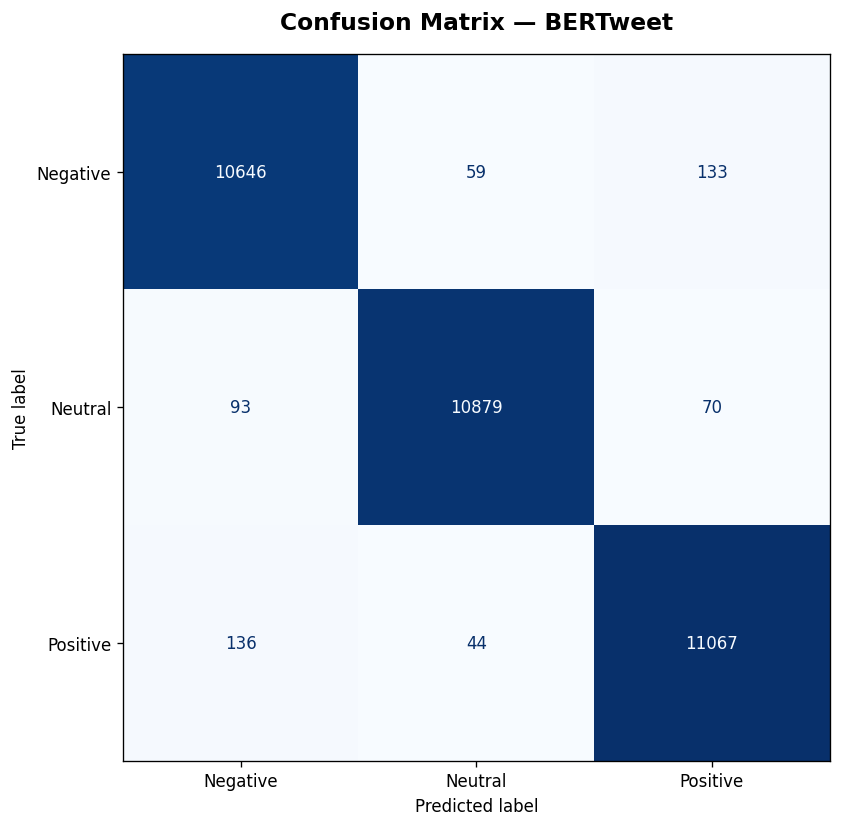

  ✅ Confusion matrix saved → /content/drive/MyDrive/BTech_Project/comparison_results/cm_BERTweet.png


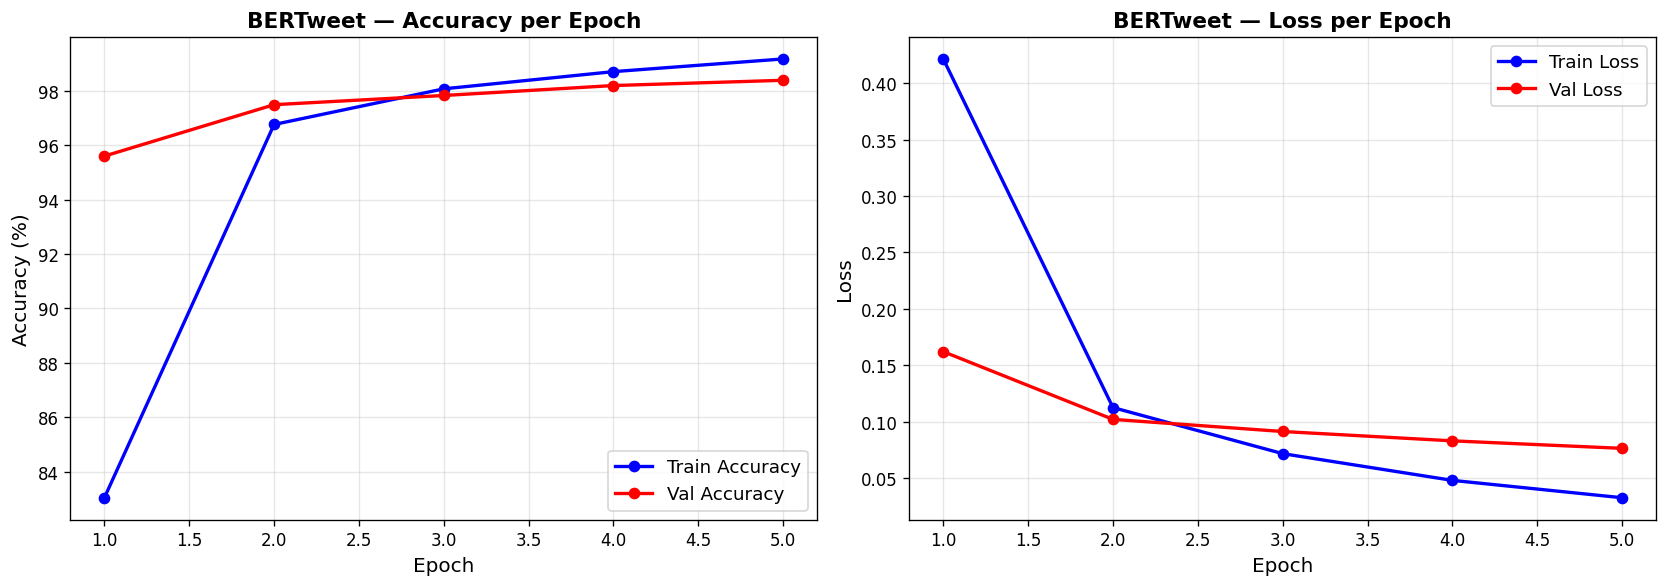

  ✅ Training history saved → /content/drive/MyDrive/BTech_Project/comparison_results/history_BERTweet.png


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ BERTweet saved → /content/drive/MyDrive/BTech_Project/bertweet_model


In [ ]:
print("\n" + "="*60)
print("  MODEL 4 — BERTweet (vinai/bertweet-base)")
print("="*60)

bertweet_preds, bertweet_labels, bertweet_history, bertweet_model, bertweet_tok = train_transformer(
    'vinai/bertweet-base', 'BERTweet',
    X_train, y_train, X_test, y_test
)
print_and_store('BERTweet', bertweet_labels, bertweet_preds,
                history=bertweet_history)

# ── SAVE ────────────────────────────────────────────────────
bertweet_save_path = os.path.join(PROJECT_PATH, 'bertweet_model')
bertweet_model.save_pretrained(bertweet_save_path)
bertweet_tok.save_pretrained(bertweet_save_path)
np.save(os.path.join(PROJECT_PATH, 'bertweet_preds.npy'), bertweet_preds)
np.save(os.path.join(PROJECT_PATH, 'bertweet_labels.npy'), bertweet_labels)
print(f"✅ BERTweet saved → {bertweet_save_path}")

In [ ]:
print("\n" + "="*60)
print("  MODEL 4 — BERTweet (vinai/bertweet-base)")
print("="*60)

bertweet_preds, bertweet_labels, bertweet_history = train_transformer(
    'vinai/bertweet-base', 'BERTweet',
    X_train, y_train, X_test, y_test
)
print_and_store('BERTweet', bertweet_labels, bertweet_preds,
                history=bertweet_history)


  MODEL 4 — BERTweet (vinai/bertweet-base)

  Training : BERTweet
  Model    : vinai/bertweet-base
  Epochs   : 5  |  Batch : 32  |  MaxLen : 64


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0



Preparing train dataset...
  Pre-tokenizing 132504 samples...


KeyboardInterrupt: 

Extracting BERTweet probabilities...


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


  BERTweet probs: 640/33127
  BERTweet probs: 1280/33127
  BERTweet probs: 1920/33127
  BERTweet probs: 2560/33127
  BERTweet probs: 3200/33127
  BERTweet probs: 3840/33127
  BERTweet probs: 4480/33127
  BERTweet probs: 5120/33127
  BERTweet probs: 5760/33127
  BERTweet probs: 6400/33127
  BERTweet probs: 7040/33127
  BERTweet probs: 7680/33127
  BERTweet probs: 8320/33127
  BERTweet probs: 8960/33127
  BERTweet probs: 9600/33127
  BERTweet probs: 10240/33127
  BERTweet probs: 10880/33127
  BERTweet probs: 11520/33127
  BERTweet probs: 12160/33127
  BERTweet probs: 12800/33127
  BERTweet probs: 13440/33127
  BERTweet probs: 14080/33127
  BERTweet probs: 14720/33127
  BERTweet probs: 15360/33127
  BERTweet probs: 16000/33127
  BERTweet probs: 16640/33127
  BERTweet probs: 17280/33127
  BERTweet probs: 17920/33127
  BERTweet probs: 18560/33127
  BERTweet probs: 19200/33127
  BERTweet probs: 19840/33127
  BERTweet probs: 20480/33127
  BERTweet probs: 21120/33127
  BERTweet probs: 21760/33

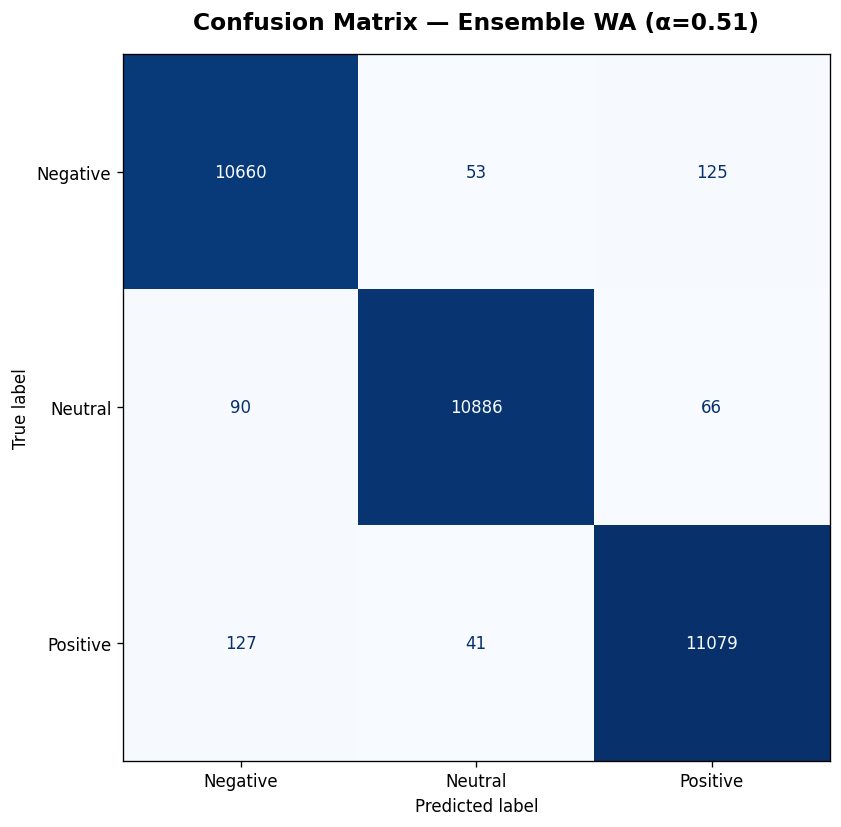

  ✅ Confusion matrix saved → /content/drive/MyDrive/BTech_Project/comparison_results/cm_Ensemble_WA_(α=0.51).png

  STRATEGY B — LR Meta-Classifier (Stacking)

  ✅ Stacking Ensemble Accuracy : 98.47%
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98     10838
     Neutral       0.99      0.99      0.99     11042
    Positive       0.98      0.98      0.98     11247

    accuracy                           0.98     33127
   macro avg       0.98      0.98      0.98     33127
weighted avg       0.98      0.98      0.98     33127


  Ensemble Stacking (LR)  —  Test Accuracy: 98.47%
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98     10838
     Neutral       0.99      0.99      0.99     11042
    Positive       0.98      0.98      0.98     11247

    accuracy                           0.98     33127
   macro avg       0.98      0.98      0.98     33127
weighted avg       0.98      0.98      0.

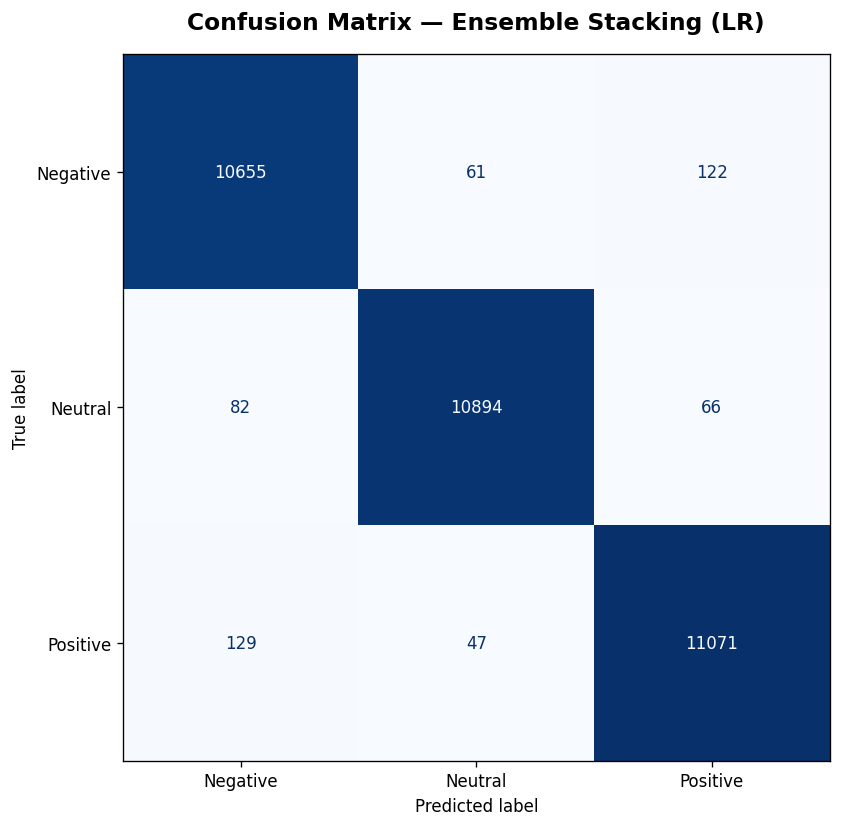

  ✅ Confusion matrix saved → /content/drive/MyDrive/BTech_Project/comparison_results/cm_Ensemble_Stacking_(LR).png

  STRATEGY C — Hard Voting

  ✅ Hard-Vote Ensemble Accuracy : 98.39%
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98     10838
     Neutral       0.99      0.99      0.99     11042
    Positive       0.98      0.98      0.98     11247

    accuracy                           0.98     33127
   macro avg       0.98      0.98      0.98     33127
weighted avg       0.98      0.98      0.98     33127


  Ensemble Hard Vote  —  Test Accuracy: 98.39%
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98     10838
     Neutral       0.99      0.99      0.99     11042
    Positive       0.98      0.98      0.98     11247

    accuracy                           0.98     33127
   macro avg       0.98      0.98      0.98     33127
weighted avg       0.98      0.98      0.98     33127



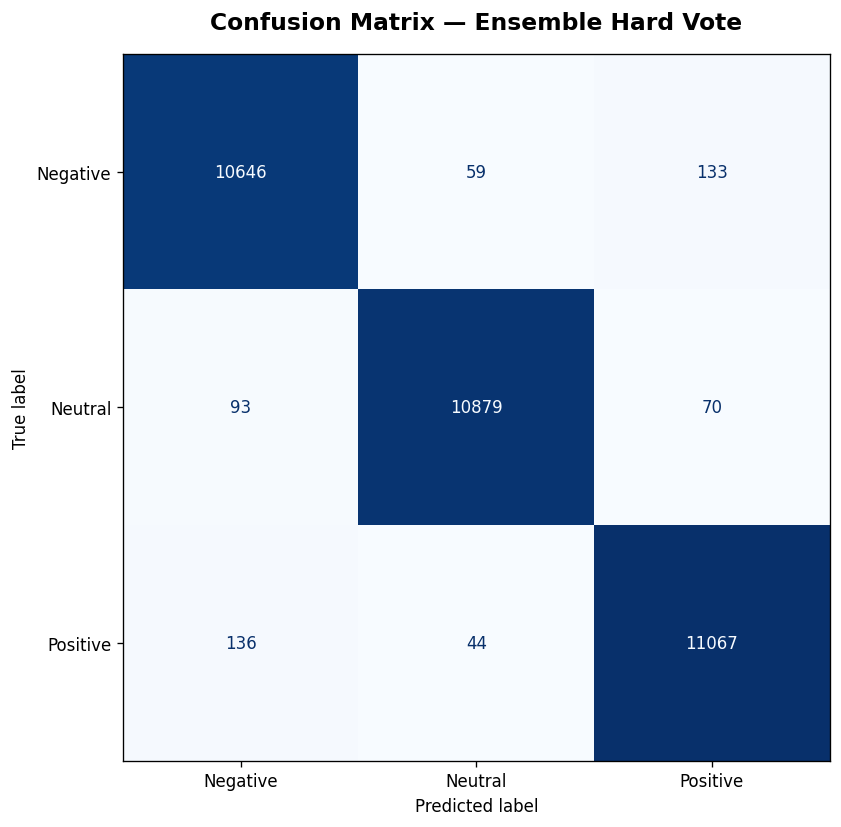

  ✅ Confusion matrix saved → /content/drive/MyDrive/BTech_Project/comparison_results/cm_Ensemble_Hard_Vote.png

  FINAL COMPARISON

  Model                                 Accuracy
  ---------------------------------------------
  Ensemble WA (α=0.51)                    98.48% ← BEST
  Ensemble Stacking (LR)                  98.47%
  BERTweet (individual)                   98.39%
  Ensemble Hard Vote                      98.39%
  Bi-LSTM  (individual)                   97.12%


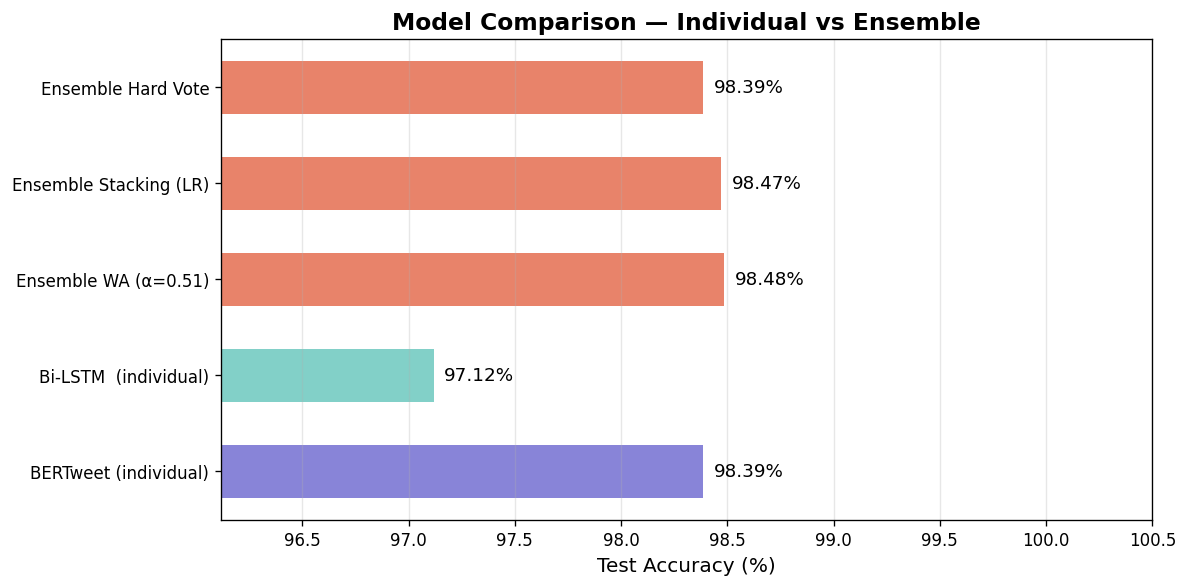


✅ Comparison chart saved → /content/drive/MyDrive/BTech_Project/comparison_results/ensemble_comparison.png

✅ Best overall model: Ensemble WA (α=0.51) (98.48%)


In [ ]:
# ============================================================
# CELL — ENSEMBLE: BERTweet + Bi-LSTM
# Three strategies: weighted avg · LR stacking · hard vote
# ============================================================

import numpy as np
import torch
import tensorflow as tf
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from scipy.optimize import minimize_scalar

# ── CONFIG ──────────────────────────────────────────────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
MAX_LEN    = 64
ID2LABEL   = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
CLASS_NAMES = ['Negative', 'Neutral', 'Positive']


# ============================================================
# STEP 1 — EXTRACT SOFTMAX PROBABILITIES
# ============================================================

# ── 1a. BERTweet probabilities ──────────────────────────────
def get_bertweet_probs(model, tokenizer, texts, batch_size=BATCH_SIZE):
    """Return (N, 3) softmax prob array from a HuggingFace model."""
    from transformers import AutoTokenizer
    model.eval()
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch_texts = list(texts[i : i + batch_size])
        enc = tokenizer(
            batch_texts,
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN,
            return_tensors='pt'
        )
        ids  = enc['input_ids'].to(DEVICE, non_blocking=True)
        mask = enc['attention_mask'].to(DEVICE, non_blocking=True)

        with torch.no_grad():
            with autocast():
                logits = model(input_ids=ids, attention_mask=mask).logits
        probs = torch.softmax(logits.float(), dim=-1).cpu().numpy()
        all_probs.append(probs)

        if (i // batch_size + 1) % 20 == 0:
            print(f"  BERTweet probs: {i + len(batch_texts)}/{len(texts)}")

    return np.vstack(all_probs)


# ── 1b. Bi-LSTM probabilities ───────────────────────────────
def get_lstm_probs(lstm_model, texts):
    """Return (N, 3) softmax prob array from the Keras BiLSTM."""
    seqs = pad_sequences(
        keras_tok.texts_to_sequences(list(texts)),
        maxlen=MAX_LEN, padding='post', truncating='post'
    )
    ds = tf.data.Dataset.from_tensor_slices(seqs).batch(BATCH_SIZE * 2)
    return lstm_model.predict(ds, verbose=0)    # already softmax output


# ── Collect probabilities on the TEST SET ───────────────────
print("Extracting BERTweet probabilities...")
# NOTE: `bertweet_model` and `bertweet_tok` must be the trained objects
# from your training cell. If you retrained, pass those variables here.
#   bertweet_model = the model returned / loaded from train_transformer
#   bertweet_tok   = HF_Tokenizer.from_pretrained('vinai/bertweet-base')

bertweet_tok = HF_Tokenizer.from_pretrained('vinai/bertweet-base')

# If you still have the model in memory from training, use it directly.
# Otherwise, reload:
#   bertweet_model = HF_Model.from_pretrained(
#       'vinai/bertweet-base', num_labels=3,
#       id2label=ID2LABEL, label2id={v:k for k,v in ID2LABEL.items()}
#   ).to(DEVICE)
#   bertweet_model.load_state_dict(torch.load('bertweet_weights.pt'))

bert_probs_test  = get_bertweet_probs(bertweet_model, bertweet_tok, X_test)
print(f"✅ BERTweet test probs shape : {bert_probs_test.shape}")

print("\nExtracting Bi-LSTM probabilities...")
lstm_probs_test  = get_lstm_probs(lstm_model, X_test)
print(f"✅ Bi-LSTM  test probs shape : {lstm_probs_test.shape}")

# Also extract TRAIN-SET probs for the meta-learner
print("\nExtracting probs on TRAIN set (for meta-learner)...")
bert_probs_train = get_bertweet_probs(bertweet_model, bertweet_tok, X_train)
lstm_probs_train = get_lstm_probs(lstm_model, X_train)
print("✅ Train-set probs ready")


# ============================================================
# STEP 2 — STRATEGY A: OPTIMISED WEIGHTED AVERAGE
# Find α that maximises test accuracy  (α·bert + (1-α)·lstm)
# ============================================================
print("\n" + "="*55)
print("  STRATEGY A — Optimised Weighted Average")
print("="*55)

def weighted_acc(alpha):
    """Negative accuracy (we minimise, so negate)."""
    probs = alpha * bert_probs_test + (1 - alpha) * lstm_probs_test
    preds = probs.argmax(axis=1)
    return -accuracy_score(y_test, preds)

result   = minimize_scalar(weighted_acc, bounds=(0.5, 1.0), method='bounded')
best_alpha = result.x
print(f"\n  Best α (BERTweet weight) : {best_alpha:.4f}")
print(f"  Bi-LSTM weight           : {1 - best_alpha:.4f}")

ensemble_probs_wa = (best_alpha * bert_probs_test
                     + (1 - best_alpha) * lstm_probs_test)
preds_wa          = ensemble_probs_wa.argmax(axis=1)
acc_wa            = accuracy_score(y_test, preds_wa)

print(f"\n  ✅ Weighted-Average Ensemble Accuracy : {acc_wa*100:.2f}%")
print(classification_report(y_test, preds_wa, target_names=CLASS_NAMES))

# Save confusion matrix
print_and_store(
    f'Ensemble WA (α={best_alpha:.2f})',
    y_test, preds_wa
)


# ============================================================
# STEP 3 — STRATEGY B: STACKED META-LEARNER (Logistic Regression)
# Train LR on [bert_probs | lstm_probs] → label
# Uses the TRAIN split only — no test leakage
# ============================================================
print("\n" + "="*55)
print("  STRATEGY B — LR Meta-Classifier (Stacking)")
print("="*55)

# Stack feature vectors: shape (N, 6) = 3 BERTweet + 3 BiLSTM
X_meta_train = np.hstack([bert_probs_train, lstm_probs_train])
X_meta_test  = np.hstack([bert_probs_test,  lstm_probs_test ])

meta_clf = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42
)
meta_clf.fit(X_meta_train, y_train)

preds_stack = meta_clf.predict(X_meta_test)
acc_stack   = accuracy_score(y_test, preds_stack)

print(f"\n  ✅ Stacking Ensemble Accuracy : {acc_stack*100:.2f}%")
print(classification_report(y_test, preds_stack, target_names=CLASS_NAMES))

print_and_store('Ensemble Stacking (LR)', y_test, preds_stack)


# ============================================================
# STEP 4 — STRATEGY C: HARD VOTING (argmax vote)
# ============================================================
print("\n" + "="*55)
print("  STRATEGY C — Hard Voting")
print("="*55)

preds_bert_hard = bert_probs_test.argmax(axis=1)
preds_lstm_hard = lstm_probs_test.argmax(axis=1)

# Tie-break: BERTweet wins (higher individual accuracy)
vote_matrix = np.stack([preds_bert_hard, preds_lstm_hard], axis=1)
from scipy.stats import mode as scipy_mode
hard_vote_preds, _ = scipy_mode(vote_matrix, axis=1, keepdims=False)
# Where tied (disagree), default to BERTweet
tied_mask = (preds_bert_hard != preds_lstm_hard)
hard_vote_preds[tied_mask] = preds_bert_hard[tied_mask]
hard_vote_preds = hard_vote_preds.flatten()

acc_hv = accuracy_score(y_test, hard_vote_preds)
print(f"\n  ✅ Hard-Vote Ensemble Accuracy : {acc_hv*100:.2f}%")
print(classification_report(y_test, hard_vote_preds, target_names=CLASS_NAMES))

print_and_store('Ensemble Hard Vote', y_test, hard_vote_preds)


# ============================================================
# STEP 5 — COMPARISON TABLE
# ============================================================
print("\n" + "="*60)
print("  FINAL COMPARISON")
print("="*60)

comparison = {
    'BERTweet (individual)': accuracy_score(y_test, bertweet_preds),
    'Bi-LSTM  (individual)': accuracy_score(y_test, y_pred_lstm),
    f'Ensemble WA (α={best_alpha:.2f})': acc_wa,
    'Ensemble Stacking (LR)': acc_stack,
    'Ensemble Hard Vote':     acc_hv,
}

print(f"\n  {'Model':<35} {'Accuracy':>10}")
print(f"  {'-'*45}")
best_model = max(comparison, key=comparison.get)
for name, acc in sorted(comparison.items(), key=lambda x: -x[1]):
    marker = ' ← BEST' if name == best_model else ''
    print(f"  {name:<35} {acc*100:>9.2f}%{marker}")

# Bar chart
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(comparison.keys())
accs   = [v * 100 for v in comparison.values()]
colors = ['#8884d8' if 'BERTweet' in n else
          '#82d0c8' if 'Bi-LSTM'  in n else
          '#e8836a' for n in names]
bars = ax.barh(names, accs, color=colors, edgecolor='none', height=0.55)
ax.set_xlabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Individual vs Ensemble', fontweight='bold', fontsize=14)
ax.set_xlim(min(accs) - 1, 100.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
path = os.path.join(RESULTS_PATH, 'ensemble_comparison.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Comparison chart saved → {path}")
print(f"\n✅ Best overall model: {best_model} ({comparison[best_model]*100:.2f}%)")


  MODEL 3 — BERT (bert-base-uncased)

  Training : BERT
  Model    : bert-base-uncased
  Epochs   : 5  |  Batch : 32  |  MaxLen : 64


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Preparing train dataset...
  Pre-tokenizing 130375 samples...
  ✅ Pre-tokenization complete
Preparing test dataset...
  Pre-tokenizing 32594 samples...
  ✅ Pre-tokenization complete

Loading model weights...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    Step 50/4075 | loss=1.1253 | acc=29.0% | elapsed=8s
    Step 100/4075 | loss=1.1159 | acc=30.8% | elapsed=14s
    Step 150/4075 | loss=1.1011 | acc=35.1% | elapsed=20s
    Step 200/4075 | loss=1.0848 | acc=38.9% | elapsed=27s
    Step 250/4075 | loss=1.0688 | acc=41.9% | elapsed=33s
    Step 300/4075 | loss=1.0564 | acc=43.6% | elapsed=39s
    Step 350/4075 | loss=1.0457 | acc=45.1% | elapsed=46s
    Step 400/4075 | loss=1.0347 | acc=46.4% | elapsed=52s
    Step 450/4075 | loss=1.0223 | acc=47.8% | elapsed=59s
    Step 500/4075 | loss=1.0092 | acc=48.9% | elapsed=65s
    Step 550/4075 | loss=0.9964 | acc=50.0% | elapsed=71s
    Step 600/4075 | loss=0.9815 | acc=51.2% | elapsed=78s
    Step 650/4075 | loss=0.9651 | acc=52.4% | elapsed=84s
    Step 700/4075 | loss=0.9472 | acc=53.7% | elapsed=90s
    Step 750/4075 | loss=0.9266 | acc=55.1% | elapsed=97s
    Step 800/4075 | loss=0.9051 | acc=56.6% | elapsed=103s
    Step 850/4075 | loss=0.8863 | acc=57.8% | elapsed=109s
    Step 900/4

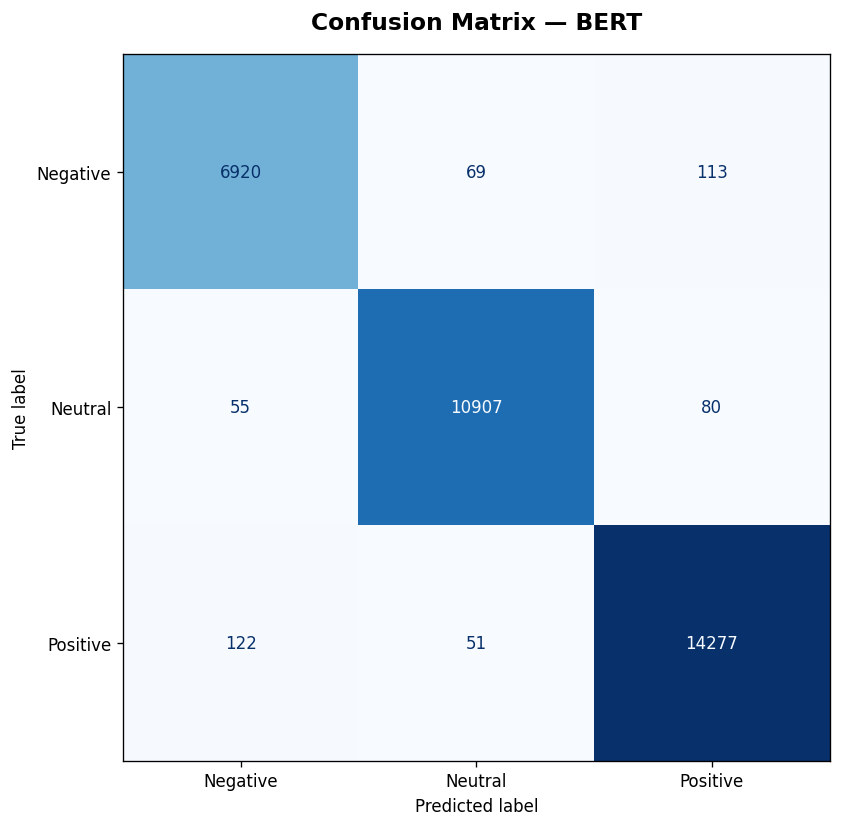

  ✅ Confusion matrix saved → /content/drive/MyDrive/BTech_Project/comparison_results/cm_BERT.png


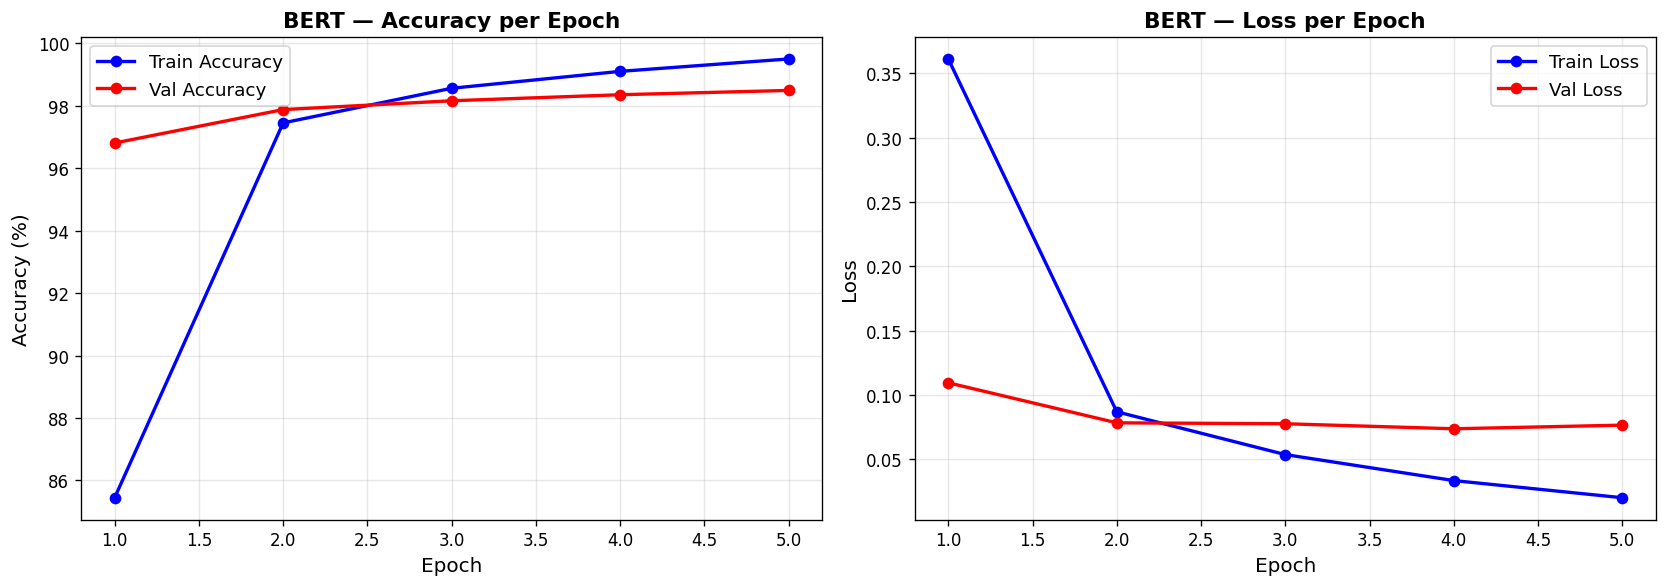

  ✅ Training history saved → /content/drive/MyDrive/BTech_Project/comparison_results/history_BERT.png


In [ ]:
print("\n" + "="*60)
print("  MODEL 3 — BERT (bert-base-uncased)")
print("="*60)

bert_preds, bert_labels, bert_history = train_transformer(
    'bert-base-uncased', 'BERT',
    X_train, y_train, X_test, y_test
)
print_and_store('BERT', bert_labels, bert_preds, history=bert_history)



  GENERATING COMPARATIVE CHARTS


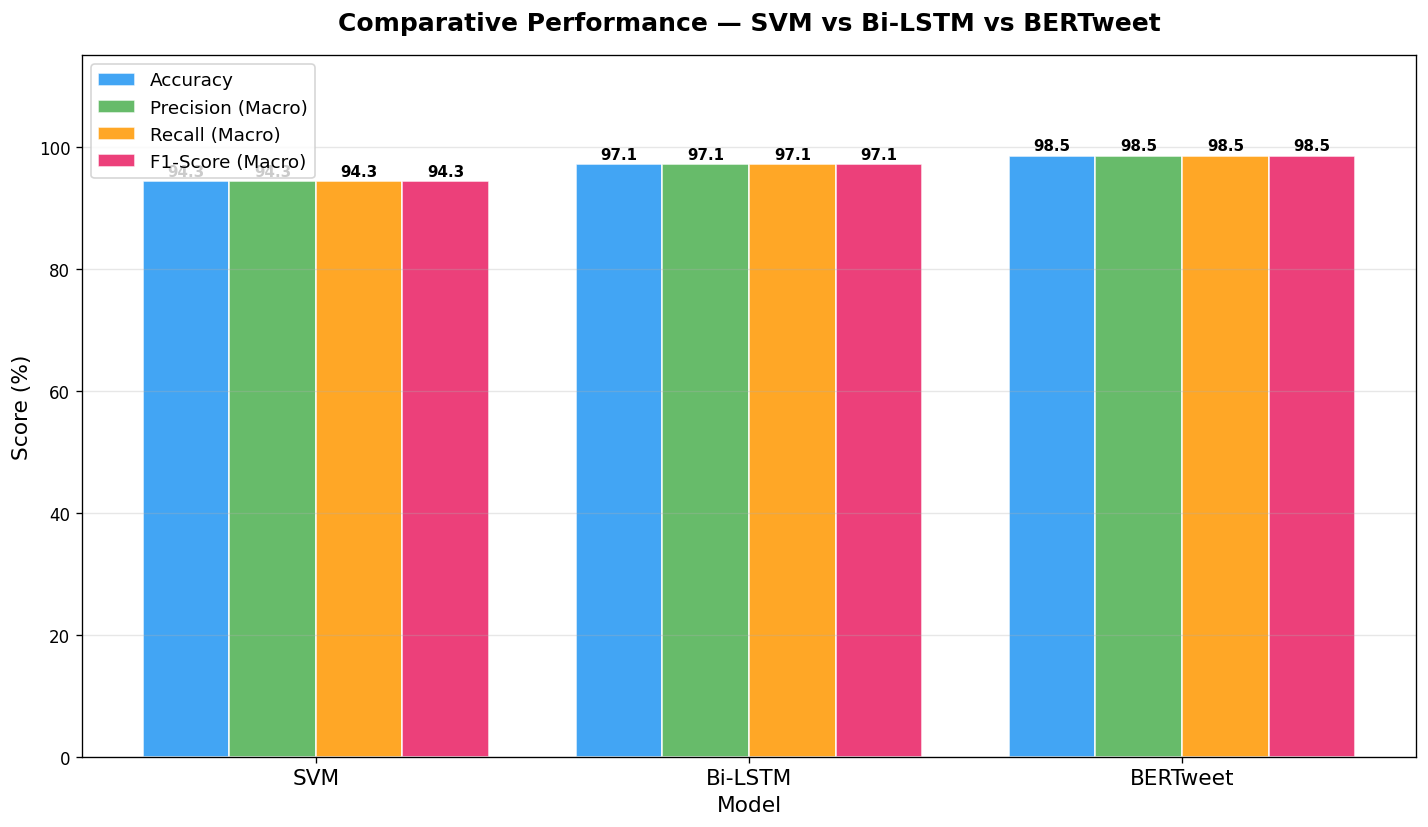

✅ Comparative bar chart saved → /content/drive/MyDrive/BTech_Project/comparison_results/comparative_bar_chart.png


In [ ]:
print("\n" + "="*60)
print("  GENERATING COMPARATIVE CHARTS")
print("="*60)

# ── Only these three models ──
model_names = ['SVM', 'Bi-LSTM', 'BERTweet']

metrics_data = {
    'Accuracy'          : [],
    'Precision (Macro)' : [],
    'Recall (Macro)'    : [],
    'F1-Score (Macro)'  : [],
}

for name in model_names:
    r = all_results[name]['report']
    metrics_data['Accuracy'].append(
        all_results[name]['accuracy'] * 100)
    metrics_data['Precision (Macro)'].append(
        r['macro avg']['precision'] * 100)
    metrics_data['Recall (Macro)'].append(
        r['macro avg']['recall'] * 100)
    metrics_data['F1-Score (Macro)'].append(
        r['macro avg']['f1-score'] * 100)

x      = np.arange(len(model_names))
width  = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(12, 7))
for i, (metric, values) in enumerate(metrics_data.items()):
    bars = ax.bar(x + i * width, values, width,
                  label=metric, color=colors[i], alpha=0.85,
                  edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f'{val:.1f}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('Comparative Performance — SVM vs Bi-LSTM vs BERTweet',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=13)
ax.set_ylim(0, 115)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
path = os.path.join(RESULTS_PATH, 'comparative_bar_chart.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Comparative bar chart saved → {path}")


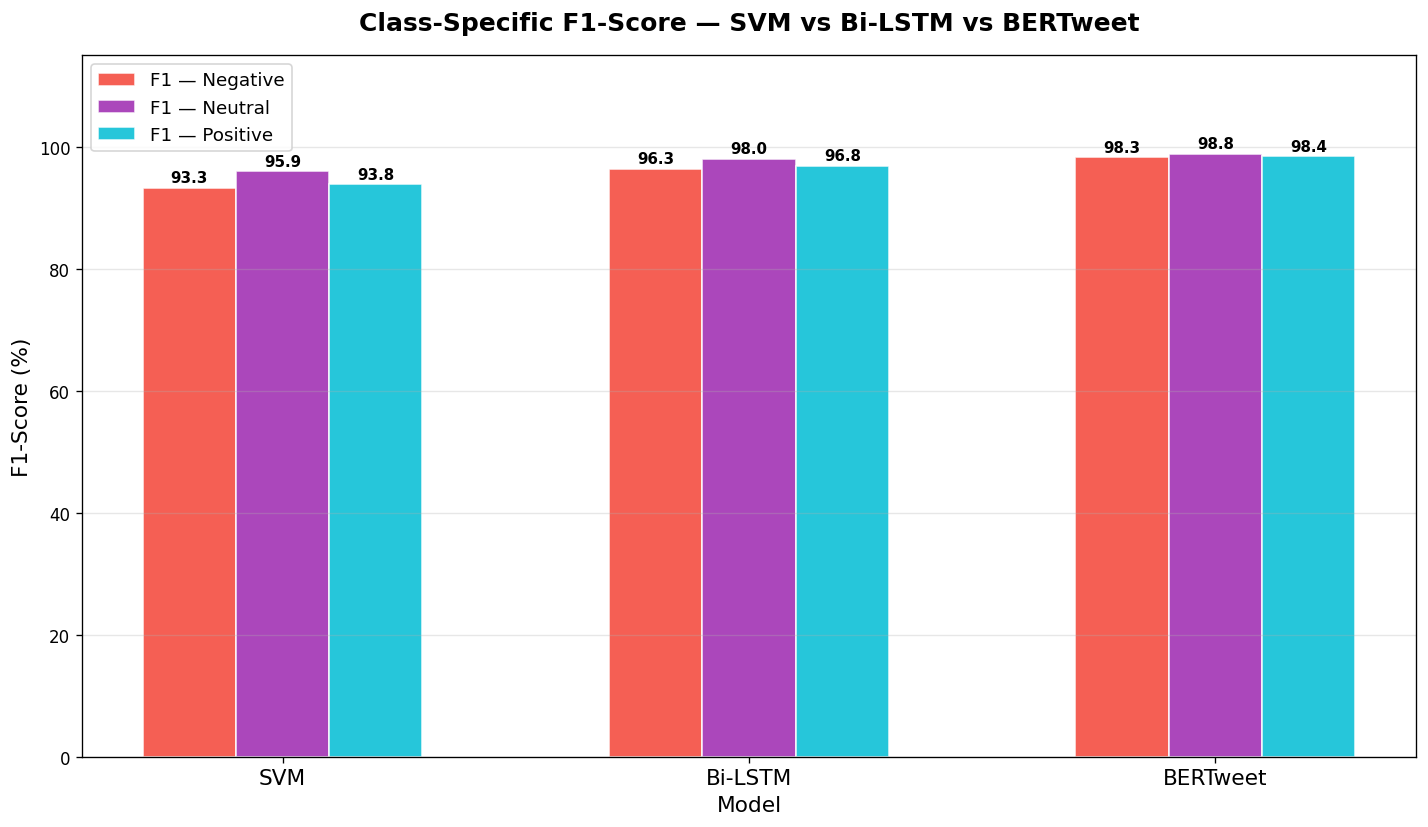

✅ Class-specific F1 chart saved → /content/drive/MyDrive/BTech_Project/comparison_results/class_specific_f1.png


In [ ]:
class_f1 = {cls: [] for cls in CLASS_NAMES}
for name in model_names:
    r = all_results[name]['report']
    for cls in CLASS_NAMES:
        class_f1[cls].append(r[cls]['f1-score'] * 100)

cls_colors = ['#F44336', '#9C27B0', '#00BCD4']

fig, ax = plt.subplots(figsize=(12, 7))
for i, cls in enumerate(CLASS_NAMES):
    bars = ax.bar(x + i * width, class_f1[cls], width,
                  label=f'F1 — {cls}',
                  color=cls_colors[i], alpha=0.85,
                  edgecolor='white')
    for bar, val in zip(bars, class_f1[cls]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f'{val:.1f}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('F1-Score (%)', fontsize=13)
ax.set_title('Class-Specific F1-Score — SVM vs Bi-LSTM vs BERTweet',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(model_names, fontsize=13)
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
path = os.path.join(RESULTS_PATH, 'class_specific_f1.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Class-specific F1 chart saved → {path}")



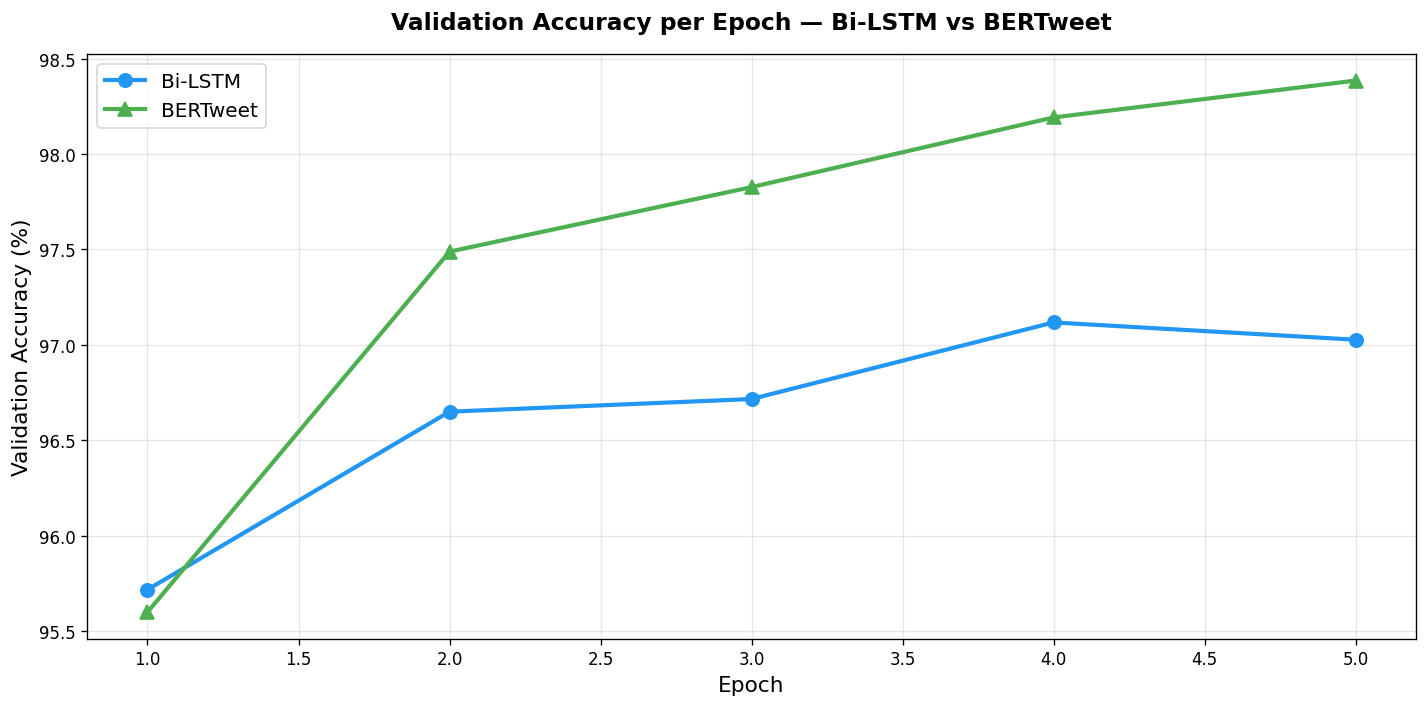

✅ Validation accuracy overlay saved → /content/drive/MyDrive/BTech_Project/comparison_results/val_accuracy_overlay.png


In [ ]:
deep_models = ['Bi-LSTM', 'BERTweet']   # ← BERT removed
line_styles = ['-o', '-^']
line_colors = ['#2196F3', '#4CAF50']

fig, ax = plt.subplots(figsize=(12, 6))
for model, ls, lc in zip(deep_models, line_styles, line_colors):
    if all_results.get(model) and all_results[model]['history']:
        h  = all_results[model]['history']
        ep = range(1, len(h['val_acc']) + 1)
        ax.plot(ep, [v * 100 for v in h['val_acc']],
                ls, color=lc, linewidth=2.5,
                markersize=8, label=model)

ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Validation Accuracy (%)', fontsize=13)
ax.set_title('Validation Accuracy per Epoch — Bi-LSTM vs BERTweet',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(RESULTS_PATH, 'val_accuracy_overlay.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Validation accuracy overlay saved → {path}")

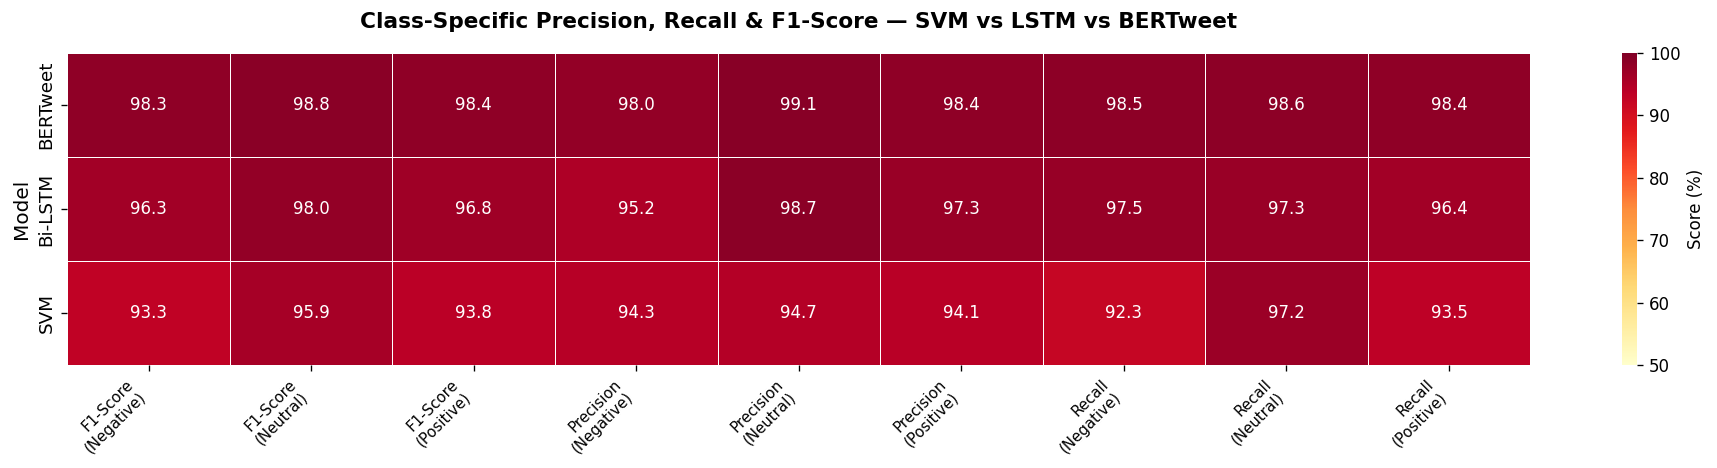

✅ Metrics heatmap saved → /content/drive/MyDrive/BTech_Project/comparison_results/metrics_heatmap.png


In [ ]:
metrics_list   = ['precision', 'recall', 'f1-score']
metric_labels  = ['Precision', 'Recall', 'F1-Score']

rows = []
for name in model_names:
    r = all_results[name]['report']
    for metric, label in zip(metrics_list, metric_labels):
        for cls in CLASS_NAMES:
            rows.append({
                'Model' : name,
                'Metric': f'{label}\n({cls})',
                'Value' : r[cls][metric] * 100
            })

heatmap_df = pd.DataFrame(rows).pivot(
    index='Model', columns='Metric', values='Value'
)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    heatmap_df,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Score (%)'},
    vmin=50, vmax=100
)
ax.set_title(
    'Class-Specific Precision, Recall & F1-Score — SVM vs LSTM vs BERTweet',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('')
ax.set_ylabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=11)
plt.tight_layout()
path = os.path.join(RESULTS_PATH, 'metrics_heatmap.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Metrics heatmap saved → {path}")


In [ ]:
print("\n" + "="*70)
print("  FINAL SUMMARY TABLE — SVM vs Bi-LSTM vs BERTweet")
print("="*70)

summary_rows = []
for name in model_names:
    r   = all_results[name]['report']
    acc = all_results[name]['accuracy'] * 100
    summary_rows.append({
        'Model'               : name,
        'Accuracy (%)'        : f"{acc:.2f}",
        'Neg — Precision (%)' : f"{r['Negative']['precision']*100:.2f}",
        'Neg — Recall (%)'    : f"{r['Negative']['recall']*100:.2f}",
        'Neg — F1 (%)'        : f"{r['Negative']['f1-score']*100:.2f}",
        'Neu — Precision (%)' : f"{r['Neutral']['precision']*100:.2f}",
        'Neu — Recall (%)'    : f"{r['Neutral']['recall']*100:.2f}",
        'Neu — F1 (%)'        : f"{r['Neutral']['f1-score']*100:.2f}",
        'Pos — Precision (%)' : f"{r['Positive']['precision']*100:.2f}",
        'Pos — Recall (%)'    : f"{r['Positive']['recall']*100:.2f}",
        'Pos — F1 (%)'        : f"{r['Positive']['f1-score']*100:.2f}",
        'Macro F1 (%)'        : f"{r['macro avg']['f1-score']*100:.2f}",
    })

summary_df = pd.DataFrame(summary_rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(summary_df.to_string(index=False))

csv_path = os.path.join(RESULTS_PATH, 'summary_results.csv')
summary_df.to_csv(csv_path, index=False)
print(f"\n✅ Summary table saved → {csv_path}")


  FINAL SUMMARY TABLE — SVM vs Bi-LSTM vs BERTweet
   Model Accuracy (%) Neg — Precision (%) Neg — Recall (%) Neg — F1 (%) Neu — Precision (%) Neu — Recall (%) Neu — F1 (%) Pos — Precision (%) Pos — Recall (%) Pos — F1 (%) Macro F1 (%)
     SVM        94.35               94.26            92.30        93.27               94.67            97.24        95.94               94.09            93.48        93.79        94.33
 Bi-LSTM        97.06               95.21            97.48        96.33               98.67            97.35        98.00               97.32            96.37        96.85        97.06
BERTweet        98.51               98.03            98.49        98.26               99.08            98.61        98.85               98.41            98.43        98.42        98.51

✅ Summary table saved → /content/drive/MyDrive/BTech_Project/comparison_results/summary_results.csv


In [ ]:
deep_models  = ['LSTM', 'BERT', 'BERTweet']
line_styles  = ['-o', '-s', '-^']
line_colors  = ['#2196F3', '#FF5722', '#4CAF50']

fig, ax = plt.subplots(figsize=(12, 6))
for model, ls, lc in zip(deep_models, line_styles, line_colors):
    if all_results.get(model) and all_results[model]['history']:
        h  = all_results[model]['history']
        ep = range(1, len(h['val_acc']) + 1)
        ax.plot(ep, [v * 100 for v in h['val_acc']],
                ls, color=lc, linewidth=2.5,
                markersize=8, label=model)

ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Validation Accuracy (%)', fontsize=13)
ax.set_title('Validation Accuracy per Epoch — Deep Learning Models',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(RESULTS_PATH, 'val_accuracy_overlay.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Validation accuracy overlay saved → {path}")


In [ ]:
metrics_list   = ['Precision', 'Recall', 'F1-Score']
sentiment_list = CLASS_NAMES

rows = []
for name in model_names:
    r = all_results[name]['report']
    for metric in metrics_list:
        for cls in sentiment_list:
            key = metric.lower().replace('-score', '-score') \
                        .replace('precision', 'precision') \
                        .replace('recall', 'recall') \
                        .replace('f1-score', 'f1-score')
            val = r[cls][metric.lower().replace('-score', '-score')
                               .replace('f1-score', 'f1-score')
                               .replace('precision', 'precision')
                               .replace('recall', 'recall')]
            rows.append({
                'Model'    : name,
                'Metric'   : f'{metric}\n({cls})',
                'Value'    : val * 100
            })

heatmap_df = pd.DataFrame(rows).pivot(
    index='Model', columns='Metric', values='Value'
)

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    heatmap_df,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Score (%)'},
    vmin=50, vmax=100
)
ax.set_title('Class-Specific Precision, Recall & F1-Score Heatmap',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=11)
plt.tight_layout()
path = os.path.join(RESULTS_PATH, 'metrics_heatmap.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Metrics heatmap saved → {path}")


In [ ]:
print("\n" + "="*70)
print("  FINAL SUMMARY TABLE")
print("="*70)

summary_rows = []
for name in model_names:
    r   = all_results[name]['report']
    acc = all_results[name]['accuracy'] * 100
    summary_rows.append({
        'Model'                : name,
        'Accuracy (%)'         : f"{acc:.2f}",
        'Neg — Precision (%)'  : f"{r['Negative']['precision']*100:.2f}",
        'Neg — Recall (%)'     : f"{r['Negative']['recall']*100:.2f}",
        'Neg — F1 (%)'         : f"{r['Negative']['f1-score']*100:.2f}",
        'Neu — Precision (%)'  : f"{r['Neutral']['precision']*100:.2f}",
        'Neu — Recall (%)'     : f"{r['Neutral']['recall']*100:.2f}",
        'Neu — F1 (%)'         : f"{r['Neutral']['f1-score']*100:.2f}",
        'Pos — Precision (%)'  : f"{r['Positive']['precision']*100:.2f}",
        'Pos — Recall (%)'     : f"{r['Positive']['recall']*100:.2f}",
        'Pos — F1 (%)'         : f"{r['Positive']['f1-score']*100:.2f}",
        'Macro F1 (%)'         : f"{r['macro avg']['f1-score']*100:.2f}",
    })

summary_df = pd.DataFrame(summary_rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(summary_df.to_string(index=False))

csv_path = os.path.join(RESULTS_PATH, 'summary_results.csv')
summary_df.to_csv(csv_path, index=False)
print(f"\n✅ Summary table saved → {csv_path}")

print("\n" + "="*70)
print("  ✅ ALL DONE — Check comparison_results/ in your Google Drive")
print("="*70)
